# Лабораторная 2. Центральность по собственному вектору

Граф собран вручную в веб-редакторе (`lab2_ui.html`) под характеристику от преподавателя:
**50 узлов, последовательность центральностей образует «яму» и «горбик»** —
т.е. сначала падает, затем возрастает до пика, потом снова опускается.

Этот ноутбук просто загружает сохранённый JSON, считает центральность через NetworkX
и строит итоговый график для отчёта.

In [2]:
import json
import networkx as nx
import numpy as np
import matplotlib.pyplot as plt

GRAPH_FILE = 'lab2_graph.json'  # сохранённый из веб-редактора

## Загрузка графа из JSON и сборка `nx.Graph`

In [3]:
with open(GRAPH_FILE, 'r', encoding='utf-8') as f:
    data = json.load(f)

n = data['n']
edges = data['edges']
positions = data.get('positions')  # координаты узлов из редактора (если сохранены)

G = nx.Graph()
G.add_nodes_from(range(n))
G.add_edges_from(edges)

print(f'Вершин: {G.number_of_nodes()}, рёбер: {G.number_of_edges()}')
print(f'Связных компонент: {nx.number_connected_components(G)}')

# nx.eigenvector_centrality_numpy кидает AmbiguousSolution на разорванном графе.
# Если что-то пошло не так — проверь редактор и пересохрани.
assert nx.is_connected(G), (
    'Граф разорван — eigenvector_centrality_numpy не работает на несвязных графах. '
    'Соедини компоненты в редакторе и пересохрани JSON.'
)

Вершин: 50, рёбер: 50
Связных компонент: 1


## Центральность по собственному вектору

`nx.eigenvector_centrality_numpy` находит главный собственный вектор матрицы смежности
через полную диагонализацию (`scipy.sparse.linalg.eigs` под капотом). Это в точности то,
что хочет преподаватель.

In [4]:
centrality = nx.eigenvector_centrality_numpy(G)
c = np.array([centrality[i] for i in range(n)])

for i in range(n):
    print(f'c({i:2d}) = {c[i]:.6f}')

c( 0) = 0.353360
c( 1) = 0.249909
c( 2) = 0.176788
c( 3) = 0.125122
c( 4) = 0.088641
c( 5) = 0.062919
c( 6) = 0.044832
c( 7) = 0.032187
c( 8) = 0.023447
c( 9) = 0.017554
c(10) = 0.013791
c(11) = 0.011701
c(12) = 0.011032
c(13) = 0.011701
c(14) = 0.013791
c(15) = 0.017554
c(16) = 0.023447
c(17) = 0.032187
c(18) = 0.044832
c(19) = 0.062919
c(20) = 0.088641
c(21) = 0.125122
c(22) = 0.176788
c(23) = 0.249909
c(24) = 0.353360
c(25) = 0.499696
c(26) = 0.353317
c(27) = 0.249817
c(28) = 0.176637
c(29) = 0.124893
c(30) = 0.088308
c(31) = 0.062439
c(32) = 0.044148
c(33) = 0.031216
c(34) = 0.022071
c(35) = 0.015606
c(36) = 0.011034
c(37) = 0.007801
c(38) = 0.005515
c(39) = 0.003899
c(40) = 0.002755
c(41) = 0.001946
c(42) = 0.001373
c(43) = 0.000967
c(44) = 0.000679
c(45) = 0.000472
c(46) = 0.000323
c(47) = 0.000213
c(48) = 0.000129
c(49) = 0.000061


## Главный график: c(i) по индексу вершины

По нему должно быть видно требуемую форму «спуск → яма → подъём → пик → спуск».

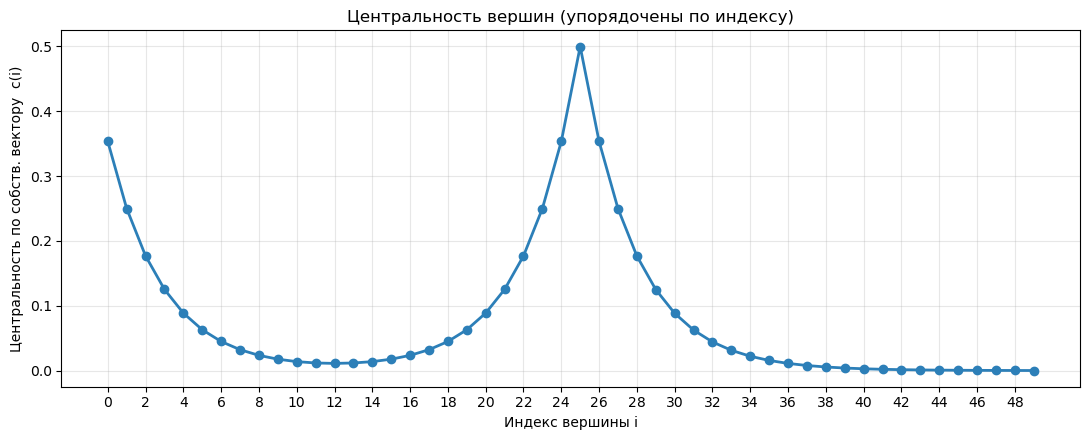

In [5]:
fig, ax = plt.subplots(figsize=(11, 4.5))
ax.plot(range(n), c, 'o-', color='#2c7fb8', linewidth=2, markersize=6)
ax.set_xlabel('Индекс вершины i')
ax.set_ylabel('Центральность по собств. вектору  c(i)')
ax.set_title('Центральность вершин (упорядочены по индексу)')
ax.grid(alpha=0.3)
ax.set_xticks(range(0, n, 2))
plt.tight_layout()
plt.show()

## Визуализация самого графа

Используем координаты, в которых ты собирал граф в редакторе.

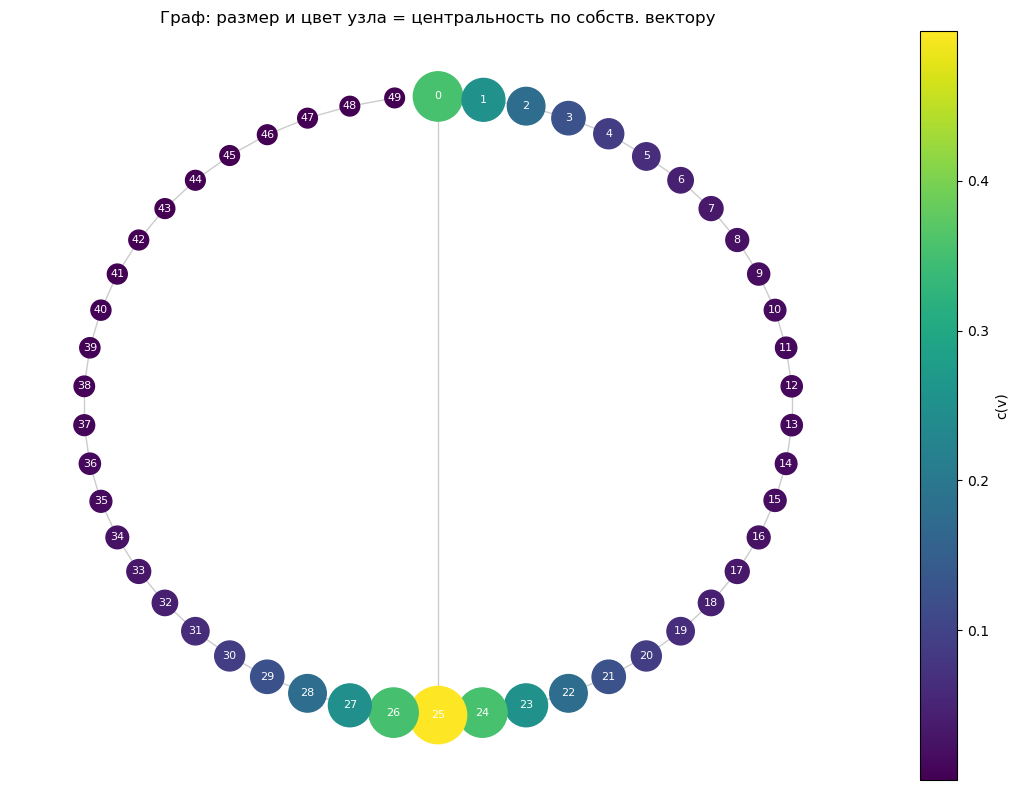

In [8]:
if positions is not None:
    pos = {i: (positions[i][0], -positions[i][1]) for i in range(n)}  # инверсия Y чтобы совпадало с canvas
else:
    pos = nx.spring_layout(G, seed=42)

fig, ax = plt.subplots(figsize=(11, 8))
node_sizes = 200 + 1500 * (c / c.max())
nx.draw_networkx_edges(G, pos, edge_color='#cccccc', width=1, ax=ax)
nodes = nx.draw_networkx_nodes(G, pos, node_size=node_sizes, node_color=c,
                                cmap='viridis', ax=ax)
nx.draw_networkx_labels(G, pos, font_size=8, font_color='white', ax=ax)
plt.colorbar(nodes, ax=ax, label='c(v)')
ax.set_title('Граф: размер и цвет узла = центральность по собств. вектору')
ax.set_axis_off()
plt.tight_layout()
plt.show()